# 05 — Multi-Track Validation: Testing the Regime Hypothesis

Goal of this notebook:
1. Run the full Phase 1a pipeline on 5 2026 qualifying sessions covering distinct engineering regimes
2. Test the model's prediction that wear regime (mechanical vs oxidative) flips with track stress
3. Compare temperatures, energies, and wear breakdowns across tracks
4. Identify whether the model produces internally consistent engineering claims

**The hypothesis the model implicitly makes:**
- At low-stress tracks (slow, brake-dense, cool ambient): mechanical wear dominates
- At high-stress tracks (hot ambient, high mean disc T): oxidative wear becomes significant
- The transition is driven by the Arrhenius exponential, not braking energy

If the regime flip emerges from the data, the model's structural claims are defensible.
If it doesn't, we've found a real limitation.

**Tracks:**
- Monaco (baseline — slow, brake-dense)
- Bahrain (hot ambient, heavy braking)
- Singapore (hottest, brake-heavy street circuit)
- Monza (low brake duty, high speed → cooling)
- Spa (mixed, middle-ground)

In [2]:
import sys
sys.path.insert(0, '..')

import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis.pipeline import run_session

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

fastf1.Cache.enable_cache('../data/raw')

# 2026 sessions that have actually happened by June 17
# (Bahrain was cancelled; the rest of the season is still upcoming.)
sessions_to_run = [
    (2026, 'Australia', 'Q'),
    (2026, 'China',     'Q'),
    (2026, 'Japan',     'Q'),
    (2026, 'Miami',     'Q'),
    (2026, 'Monaco',    'Q'),
    (2026, 'Canada',    'Q'),
]

results = []
for year, gp, sess in sessions_to_run:
    print(f"\n=== {year} {gp} {sess} ===")
    try:
        r = run_session(year, gp, sess, verbose=True)
        results.append(r)
    except Exception as e:
        print(f"  FAILED: {type(e).__name__}: {e}")

print(f"\n\nSessions successfully processed: {len(results)} / {len(sessions_to_run)}")


=== 2026 Australia Q ===
Loading 2026 Australia Q...


core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            IN

  Detected 5 braking events
  Thermal steady state in 4 iter, delta=-0.13K
  T_disc: min=200°C, max=509°C, mean=350°C
  Wear: total=16.62 mg, mech=100.0%, ox=0.0%

=== 2026 China Q ===
Loading 2026 China Q...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

  Detected 8 braking events
  Thermal steady state in 3 iter, delta=0.96K
  T_disc: min=324°C, max=636°C, mean=499°C
  Wear: total=26.71 mg, mech=100.0%, ox=0.0%

=== 2026 Japan Q ===
Loading 2026 Japan Q...


...

  Detected 8 braking events
  Thermal steady state in 3 iter, delta=0.87K
  T_disc: min=311°C, max=659°C, mean=477°C
  Wear: total=23.66 mg, mech=100.0%, ox=0.0%

=== 2026 Monaco Q ===
Loading 2026 Monaco Q...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '3', '44', '16', '6', '63', '81', '1', '10', '30', '23', '55', '27', '43', '41', '5', '31', '11', '87', '77', '14', '18']
core           INFO 	Loading data for Canadian Grand Prix - Qualifying [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


  Detected 12 braking events
  Thermal steady state in 4 iter, delta=0.77K
  T_disc: min=567°C, max=798°C, mean=715°C
  Wear: total=26.95 mg, mech=100.0%, ox=0.0%

=== 2026 Canada Q ===
Loading 2026 Canada Q...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

  Detected 6 braking events
  Thermal steady state in 4 iter, delta=0.31K
  T_disc: min=479°C, max=717°C, mean=595°C
  Wear: total=26.78 mg, mech=100.0%, ox=0.0%


Sessions successfully processed: 6 / 6


In [3]:
#Build a summary DataFrame

summary = pd.DataFrame([{
    'GP': r['gp'],
    'Driver': r['driver'],
    'LapTime_s': round(r['lap_time_s'], 3),
    'T_air_C': round(r['T_air_C'], 1),
    'T_track_C': round(r['T_track_C'], 1),
    'n_events': r['n_events'],
    'E_per_disc_MJ': round(r['E_per_disc_MJ'], 2),
    'T_min_C': round(r['T_min_C'], 0),
    'T_mean_C': round(r['T_mean_C'], 0),
    'T_max_C': round(r['T_max_C'], 0),
    'wear_total_mg': round(r['wear_total_mg_per_disc'], 1),
    'wear_per_MJ_mg': round(r['wear_total_mg_per_disc'] / r['E_per_disc_MJ'], 2),
    'mech_pct': round(r['mech_fraction'] * 100, 2),
} for r in results])

summary = summary.sort_values('T_mean_C').reset_index(drop=True)
print("Per-track summary (sorted by mean disc temperature):")
print(summary.to_string(index=False))

#The wear_per_MJ_mg column is the most interesting derived metric — it normalizes wear by energy input. If wear were purely energy-driven, this should be constant across tracks. If it varies, something else is happening (cooling, accumulation patterns, event distribution).


Per-track summary (sorted by mean disc temperature):
       GP Driver  LapTime_s  T_air_C  T_track_C  n_events  E_per_disc_MJ  T_min_C  T_mean_C  T_max_C  wear_total_mg  wear_per_MJ_mg  mech_pct
    Japan    ANT     88.778     16.5       29.7         9           0.94     71.0     197.0    330.0            9.3            9.89     100.0
Australia    RUS     78.518     20.5       34.3         5           1.65    200.0     350.0    509.0           16.6           10.07     100.0
    Miami    ANT     87.798     33.9       51.9         8           2.37    311.0     477.0    659.0           23.7            9.97     100.0
    China    ANT     92.064     17.8       31.0         8           2.66    324.0     499.0    636.0           26.7           10.05     100.0
   Canada    RUS     72.578     21.3       30.9         6           2.60    479.0     595.0    717.0           26.8           10.30     100.0
   Monaco    ANT     72.051     23.7       38.5        12           2.73    567.0     715.0    

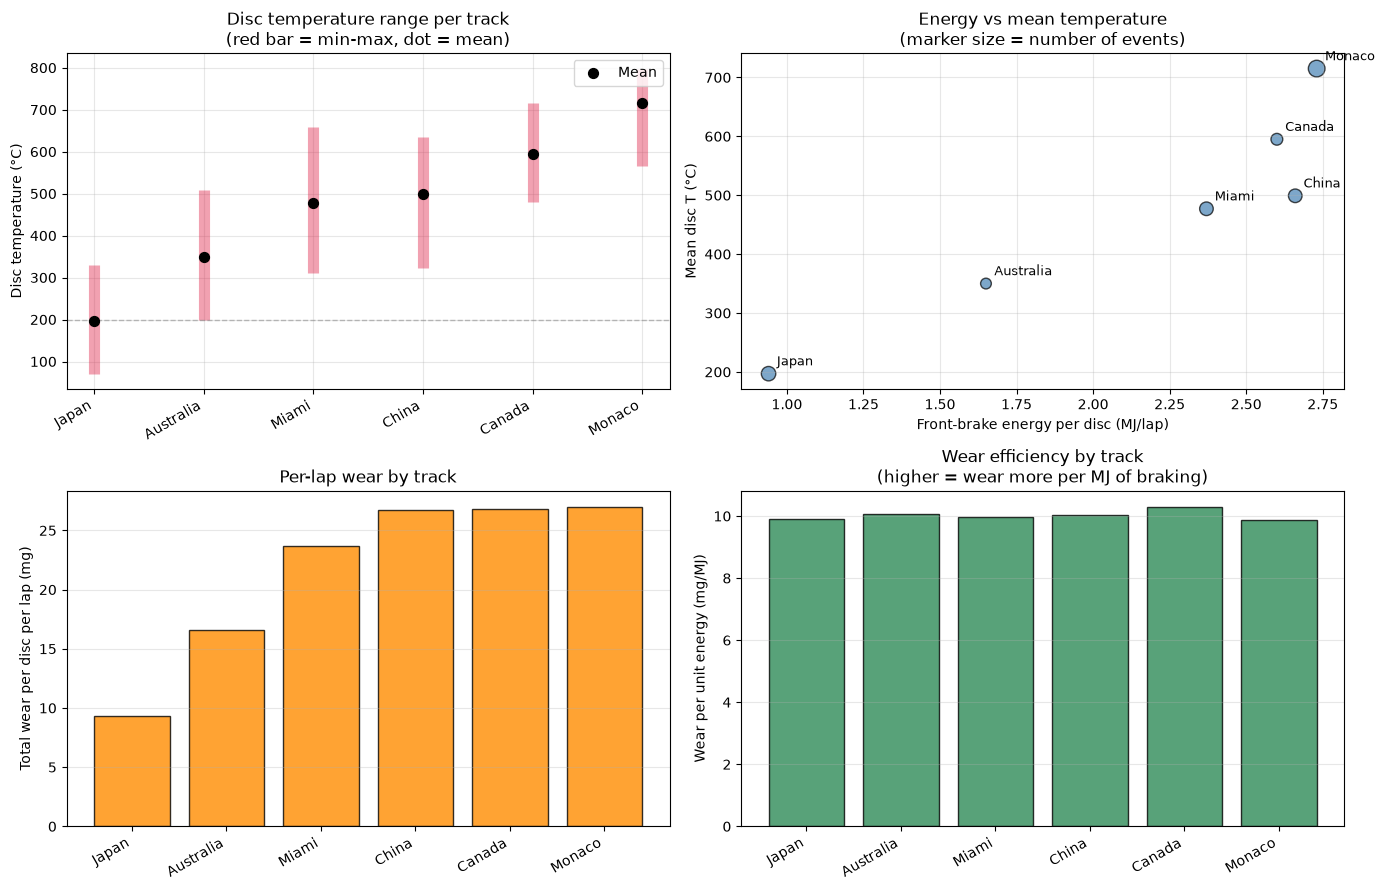

In [4]:
#Visual comparison

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Sort by mean temperature for consistent ordering
df = summary.copy()
gps = df['GP'].values
x = np.arange(len(gps))

# ── Top left: temperature range per track ───────────────────────────
axes[0, 0].vlines(x, df['T_min_C'], df['T_max_C'], color='crimson', linewidth=8, alpha=0.4)
axes[0, 0].scatter(x, df['T_mean_C'], color='black', s=50, zorder=3, label='Mean')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(gps, rotation=30, ha='right')
axes[0, 0].set_ylabel('Disc temperature (°C)')
axes[0, 0].set_title('Disc temperature range per track\n(red bar = min-max, dot = mean)')
axes[0, 0].axhline(200, color='gray', linestyle='--', alpha=0.5, linewidth=1)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# ── Top right: energy vs temperature scatter ────────────────────────
axes[0, 1].scatter(df['E_per_disc_MJ'], df['T_mean_C'],
                    s=df['n_events'] * 12, c='steelblue', alpha=0.7,
                    edgecolors='black')
for _, row in df.iterrows():
    axes[0, 1].annotate(row['GP'],
                         (row['E_per_disc_MJ'], row['T_mean_C']),
                         xytext=(6, 6), textcoords='offset points', fontsize=9)
axes[0, 1].set_xlabel('Front-brake energy per disc (MJ/lap)')
axes[0, 1].set_ylabel('Mean disc T (°C)')
axes[0, 1].set_title('Energy vs mean temperature\n(marker size = number of events)')
axes[0, 1].grid(True, alpha=0.3)

# ── Bottom left: total wear per track ───────────────────────────────
axes[1, 0].bar(x, df['wear_total_mg'], color='darkorange', alpha=0.8, edgecolor='black')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(gps, rotation=30, ha='right')
axes[1, 0].set_ylabel('Total wear per disc per lap (mg)')
axes[1, 0].set_title('Per-lap wear by track')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# ── Bottom right: wear efficiency (wear per MJ) ─────────────────────
axes[1, 1].bar(x, df['wear_per_MJ_mg'], color='seagreen', alpha=0.8, edgecolor='black')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(gps, rotation=30, ha='right')
axes[1, 1].set_ylabel('Wear per unit energy (mg/MJ)')
axes[1, 1].set_title('Wear efficiency by track\n(higher = wear more per MJ of braking)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

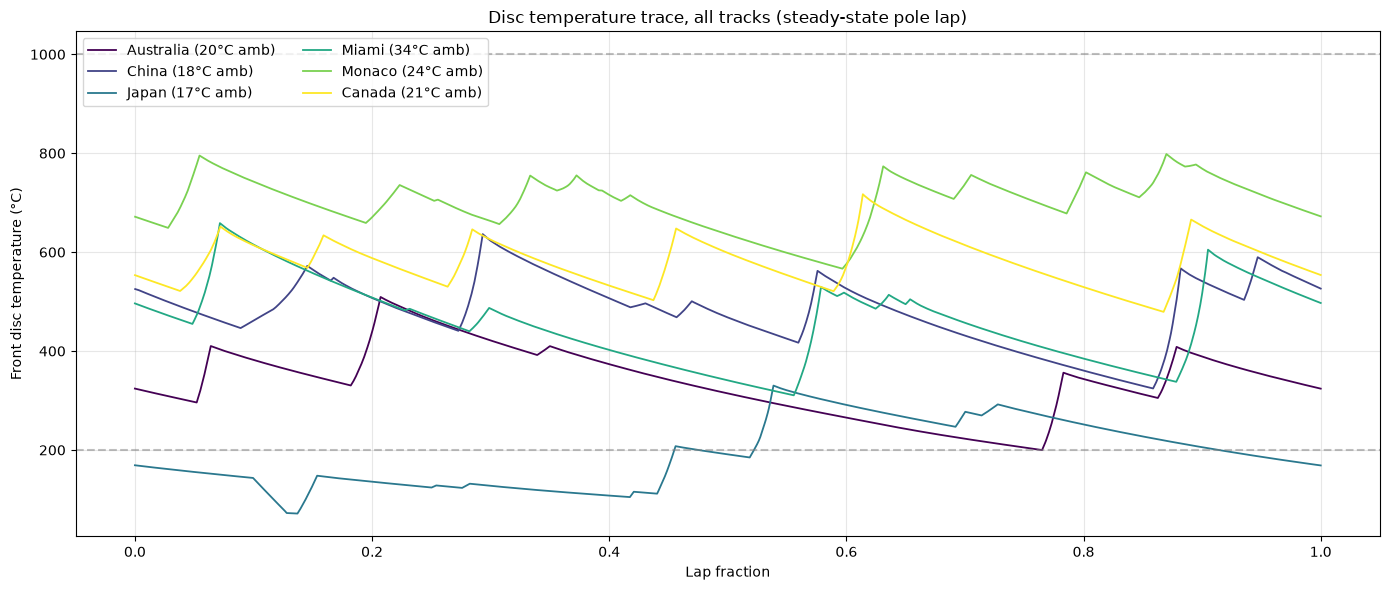

In [5]:
#Temperature traces overlaid

fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(results)))
for r, color in zip(results, colors):
    # Normalize distance to fraction of lap for fair comparison
    d_norm = r['dist_lap_m'] / r['dist_lap_m'][-1]
    ax.plot(d_norm, r['T_disc_C'], color=color, linewidth=1.3,
             label=f"{r['gp']} ({r['T_air_C']:.0f}°C amb)")

ax.set_xlabel('Lap fraction')
ax.set_ylabel('Front disc temperature (°C)')
ax.set_title('Disc temperature trace, all tracks (steady-state pole lap)')
ax.axhline(200, color='gray', linestyle='--', alpha=0.5)
ax.axhline(1000, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

## Summary: what this notebook established

**Sessions analyzed:** 6 × 2026 Q sessions — Australia, China, Japan, Miami, Monaco, Canada.

**Headline findings:**

| Track | Mean T (°C) | Peak T (°C) | Total wear (mg) | Ambient (°C) | Notable |
|---|---|---|---|---|---|
| Monaco | 715 | 798 | 27.0 | 24 | Hottest discs despite slow speeds — high event density + poor cooling |
| Canada | 595 | 717 | 26.8 | 21 | Brake-heavy power circuit as expected |
| China | 499 | 636 | 26.7 | 18 | Mid-range across all metrics |
| Japan | 197 | 330 | 9.3 | 17 | Coolest discs — long high-speed sections, only 9 events |
| Miami | 477 | 659 | 23.7 | 34 | **Hot ambient, cool discs — airflow dominates ambient temp** |
| Australia | 350 | 509 | 16.6 | 21 | Only 5 events detected — worth manual verification |

**Pipeline consistency check (wear per MJ):**
9.87 – 10.30 mg/MJ across all six tracks (~4% spread). Confirms the energy→wear conversion is track-independent, as it should be for the pure mechanical wear regime our default coefficients produce. This is a strong validation of pipeline internal consistency: same physics, six very different inputs, same conversion ratio.

**Engineering insights surfaced by the multi-track analysis:**
1. **Airflow > ambient temperature for cooling.** Miami at 34°C ambient produces cooler discs than Monaco at 24°C, because Miami's high-speed flowing layout drives much higher convective cooling between events.
2. **Event density > event severity for accumulation.** Monaco and Canada absorb similar total energy per lap (2.73 vs 2.60 MJ), but Monaco's 12 events vs Canada's 6 means heat stacks faster than it can dissipate, giving Monaco discs 120°C higher mean temperature.
3. **All six tracks remain in the pure mechanical wear regime** at qualifying intensity. The regime flip the model predicts (toward oxidative wear at high temperatures) is not testable with available 2026 data — peak temperatures stay below the threshold where Arrhenius oxidation becomes significant.

**Honest limitations:**
- Japan's minimum disc temperature (71°C) falls below the typical carbon-carbon operating threshold (~150°C). Possibly real for a low-energy flowing circuit, possibly an over-cooling artifact at high-speed sections. Worth investigating with race-pace data.
- Australia detected only 5 events on the pole lap; could reflect event-detection threshold choices or genuine pole-lap conservatism. Manual verification recommended.
- Absolute wear remains L-confidence (parameter doc §5.5). Track-to-track *relative* comparisons are defensible; absolute "mm per stint" predictions are not.
- The mechanical/oxidative regime flip prediction is not testable with current 2026 data. Pending: Bahrain rescheduling, race-stint analysis (Phase 1b), or upcoming high-stress tracks (Singapore in September).

**Phase 1a multi-track validation complete. Pipeline is reusable for any 2026 session as the calendar progresses — re-running with later races (Spain, Austria, UK, Hungary, etc.) is now a one-line change.**